# Практическое задание 3. Линейная и логистическая регрессия

## 1. Линейная регрессия

**Задача:** предсказать цену бриллианта (`price`) по его характеристикам.

**Датасет:** `diamonds` из библиотеки `seaborn` — содержит ~54 000 записей о бриллиантах.  
Признаки: `carat`, `cut`, `color`, `clarity`, `depth`, `table`, `x`, `y`, `z`.

**Алгоритм предобработки:**
- Проверка пропущенных значений (`df.isnull().sum()`)
- Анализ выбросов через `df.boxplot()`
- Кодирование категориальных признаков (`cut`, `color`, `clarity`) через `pd.get_dummies`
- Удаление выбросов по IQR для столбца `carat`

### 1.1 Загрузка данных и первичный анализ

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = sns.load_dataset('diamonds')
print(df.shape)
df.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### 1.2 Проверка пропущенных значений

In [2]:
print(df.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


Пропущенные значения отсутствуют. Датасет полный — дополнительное заполнение не требуется.

### 1.3 Анализ выбросов (до обработки)

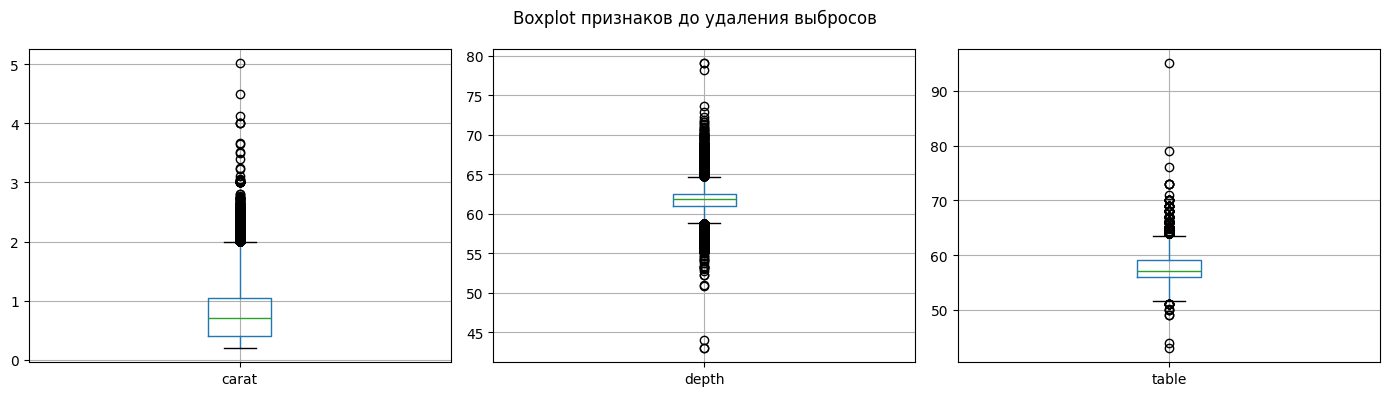

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df.boxplot(column=['carat'], ax=axes[0])
df.boxplot(column=['depth'], ax=axes[1])
df.boxplot(column=['table'], ax=axes[2])
plt.suptitle('Boxplot признаков до удаления выбросов')
plt.tight_layout()
plt.show()

### 1.4 Удаление выбросов по IQR (столбец `carat`)

In [4]:
Q1 = df['carat'].quantile(0.25)
Q3 = df['carat'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['carat'] >= Q1 - 1.5 * IQR) & (df['carat'] <= Q3 + 1.5 * IQR)]
print(f'Размер датасета после удаления выбросов: {df.shape}')

Размер датасета после удаления выбросов: (52051, 10)


### 1.5 Анализ выбросов (после обработки)

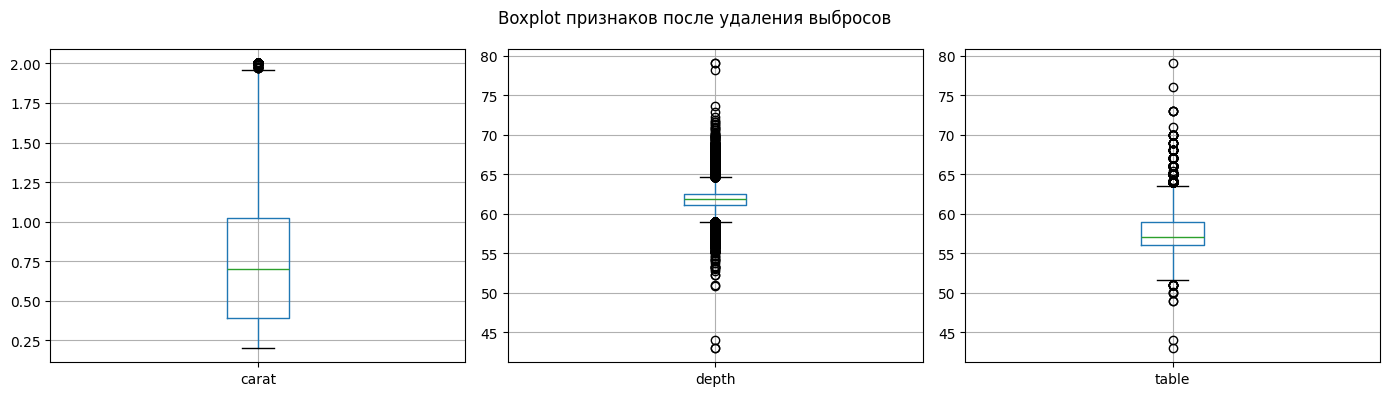

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df.boxplot(column=['carat'], ax=axes[0])
df.boxplot(column=['depth'], ax=axes[1])
df.boxplot(column=['table'], ax=axes[2])
plt.suptitle('Boxplot признаков после удаления выбросов')
plt.tight_layout()
plt.show()

### 1.6 Кодирование категориальных признаков

In [6]:
df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)
df_encoded.head()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,True,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,False,True,...,False,False,True,False,False,False,False,False,True,False


### 1.7 Обучение модели линейной регрессии

In [7]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
print(model_lr)

LinearRegression()


### 1.8 Оценка качества модели

In [8]:
y_pred = model_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.4f}')

MSE:  1020639.31
RMSE: 1010.27
R²:   0.9112


**Интерпретация метрик:**
- **MSE / RMSE** — средняя квадратичная ошибка; чем меньше, тем точнее модель.
- **R²** — коэффициент детерминации; значение близкое к 1 означает высокое качество.

### 1.9 Сравнение реальных и предсказанных значений

In [9]:
results_lr = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)}, index=y_test.index)
print(results_lr.head(10).to_string())

       Actual  Predicted
22853   10888    8757.18
508      2822    3251.60
24044     633    -239.79
33203     820    1402.62
41830    1252    1576.88
25153   13725    9662.73
29571     705     615.16
35413     900     360.66
38695    1041     996.56
22425   10450   10069.33


### 1.10 Визуализация: реальные vs предсказанные значения

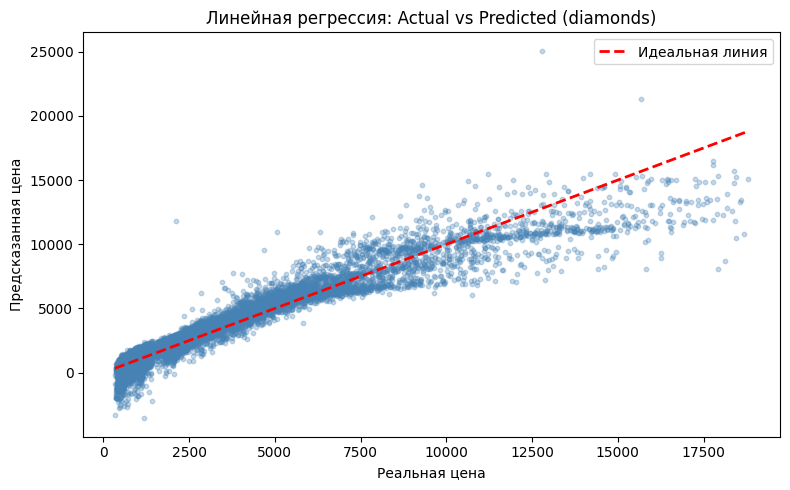

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Линейная регрессия: Actual vs Predicted (diamonds)')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Логистическая регрессия

**Задача:** классификация опухоли — злокачественная (1) или доброкачественная (0).

**Датасет:** `Breast Cancer Wisconsin` из `sklearn.datasets` — 569 записей, 30 числовых признаков (радиус, текстура, периметр и др.).

**Алгоритм предобработки:**
- Анализ пропущенных значений
- Масштабирование признаков через `StandardScaler`
- Разбивка на обучающую и тестовую выборки

### 2.1 Загрузка данных и первичный анализ

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc['target'] = data.target  # 1 = benign (доброкачественная), 0 = malignant (злокачественная)
print(df_bc.shape)
df_bc.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2.2 Проверка пропущенных значений

In [12]:
print(df_bc.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


Пропущенные значения отсутствуют. Датасет полный.

### 2.3 Распределение классов

target
1    357
0    212
Name: count, dtype: int64


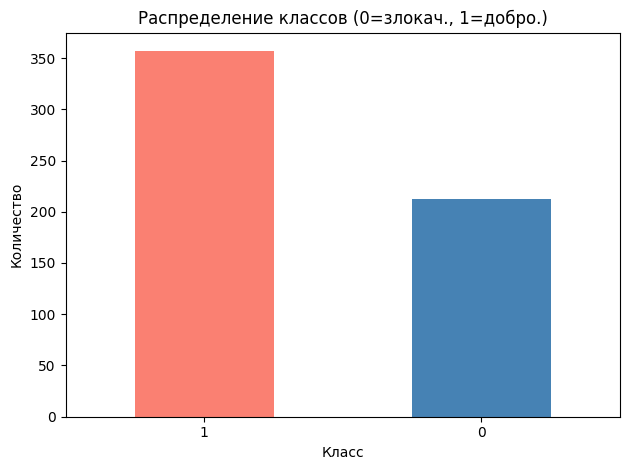

In [13]:
print(df_bc['target'].value_counts())
df_bc['target'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'],
                                     title='Распределение классов (0=злокач., 1=добро.)')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Анализ признаков (корреляционная матрица, топ-10)

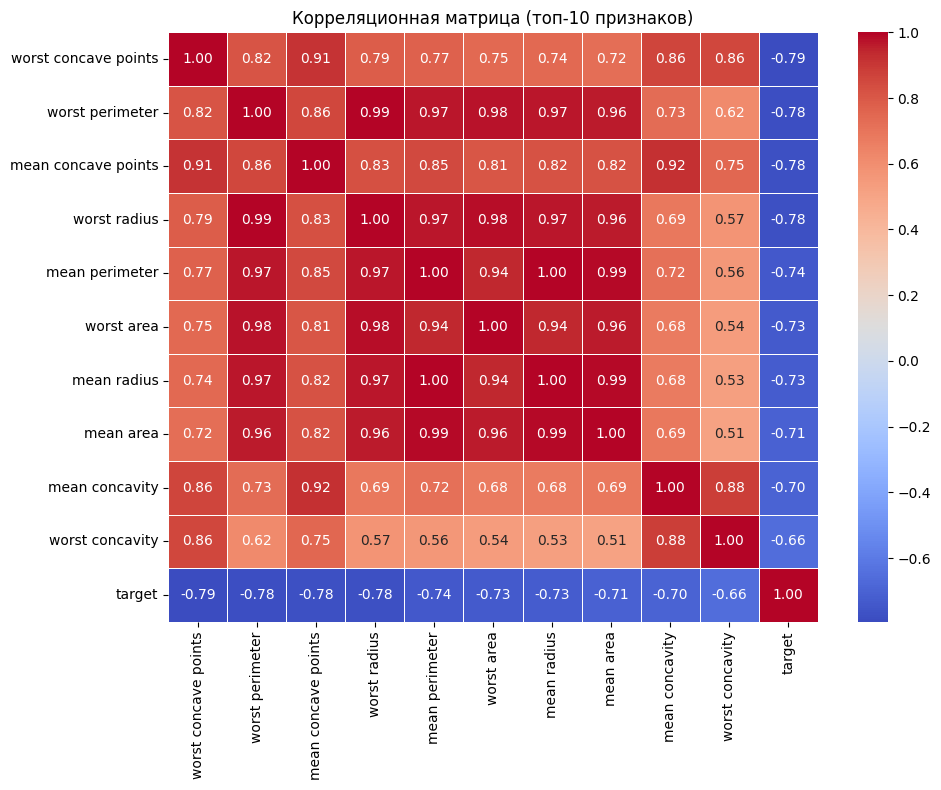

In [14]:
top_features = df_bc.corr()['target'].abs().sort_values(ascending=False)[1:11].index
plt.figure(figsize=(10, 8))
sns.heatmap(df_bc[list(top_features) + ['target']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица (топ-10 признаков)')
plt.tight_layout()
plt.show()

### 2.5 Масштабирование и обучение модели

In [15]:
X_bc = df_bc.drop(columns=['target'])
y_bc = df_bc['target']

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

scaler = StandardScaler()
X_bc_train_sc = scaler.fit_transform(X_bc_train)
X_bc_test_sc  = scaler.transform(X_bc_test)

model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_bc_train_sc, y_bc_train)
print(model_log)

LogisticRegression(max_iter=1000, random_state=42)


### 2.6 Оценка качества модели

In [16]:
y_bc_pred = model_log.predict(X_bc_test_sc)

acc = accuracy_score(y_bc_test, y_bc_pred)
roc = roc_auc_score(y_bc_test, model_log.predict_proba(X_bc_test_sc)[:, 1])

print(f'Accuracy: {acc:.4f}')
print(f'ROC-AUC:  {roc:.4f}')
print()
print(classification_report(y_bc_test, y_bc_pred,
      target_names=['Злокачественная (0)', 'Доброкачественная (1)']))

Accuracy: 0.9825
ROC-AUC:  0.9954

                       precision    recall  f1-score   support

  Злокачественная (0)       0.98      0.98      0.98        42
Доброкачественная (1)       0.99      0.99      0.99        72

             accuracy                           0.98       114
            macro avg       0.98      0.98      0.98       114
         weighted avg       0.98      0.98      0.98       114



**Интерпретация:**
- **Accuracy** — доля правильно классифицированных наблюдений.
- **ROC-AUC** — площадь под ROC-кривой; значение 1.0 — идеальный классификатор.
- **Precision / Recall / F1** — метрики для оценки по каждому классу отдельно.

### 2.7 Матрица ошибок (Confusion Matrix)

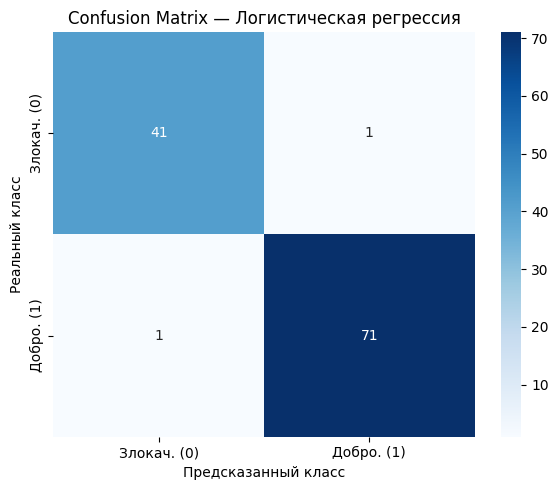

In [17]:
cm = confusion_matrix(y_bc_test, y_bc_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Злокач. (0)', 'Добро. (1)'],
            yticklabels=['Злокач. (0)', 'Добро. (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Реальный класс')
plt.title('Confusion Matrix — Логистическая регрессия')
plt.tight_layout()
plt.show()

### 2.8 ROC-кривая

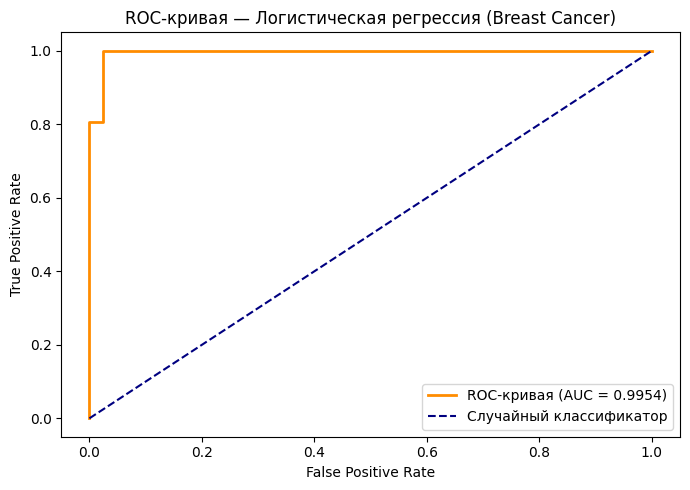

In [18]:
fpr, tpr, _ = roc_curve(y_bc_test, model_log.predict_proba(X_bc_test_sc)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая — Логистическая регрессия (Breast Cancer)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 2.9 Сравнение реальных и предсказанных меток

In [19]:
results_log = pd.DataFrame({'Actual': y_bc_test.values, 'Predicted': y_bc_pred}, index=y_bc_test.index)
print(results_log.head(15).to_string())

     Actual  Predicted
256       0          0
428       1          1
501       0          0
363       1          1
564       0          0
464       1          1
358       1          1
343       0          0
516       0          0
567       0          0
292       1          1
199       0          0
527       1          1
121       0          0
353       0          0


### 2.10 Анализ неверных предсказаний

In [20]:
errors = results_log[results_log['Actual'] != results_log['Predicted']]
print(f'Количество ошибочных предсказаний: {len(errors)}')
print(errors.to_string())

Количество ошибочных предсказаний: 2
     Actual  Predicted
541       1          0
73        0          1
